# 05 · คำถามข้อ 5: โซเชียลมีเดียกับการนอน และพฤติกรรมประจำวันกับสามมิติ

สองส่วน

1. ตอบคำถามข้อ 5 ตรง ๆ: คนที่ใช้โซเชียลมีเดียมากกว่า นอนน้อยกว่าหรือนอนแย่กว่าหรือไม่ (r และ rho ของชั่วโมงใช้งานกับชั่วโมงนอนและคุณภาพการนอน)
2. heatmap ของสหสัมพันธ์ระหว่างพฤติกรรม 5 อย่างกับคะแนนสามมิติ เพื่อดูว่าพฤติกรรมใดเกี่ยวกับมิติใด
   สีแดงคือสัมพันธ์ทางบวก (ยิ่งมากคะแนนยิ่งสูง) สีน้ำเงินคือทางลบ

In [1]:
import os
import pathlib
import sys

# notebook.nvim starts the kernel in nvim's cwd; step into codingpy/ so common.py
# and data/ are found when the notebook is opened from the repo root
if pathlib.Path("codingpy/common.py").is_file():
    os.chdir("codingpy")
    sys.path.insert(0, os.getcwd())

%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from common import DIMENSIONS, FIG_DIR, THAI_FONT, load_data, passed_attention

df = passed_attention(load_data())  # the sample every research question uses
print(f"{len(df)} respondents passed the attention check")

107 respondents passed the attention check


In [3]:
INTERACTION_COLS = {
    "social_media_hours": "ชั่วโมงโซเชียล",
    "news_days": "วันติดตามข่าว",
    "sleep_hours": "ชั่วโมงนอน",
    "exercise_days": "วันออกกำลังกาย",
    "sleep_quality": "คุณภาพการนอน",
}

INTERACTION_FIG_PATH = FIG_DIR / "q5-interaction-dass.png"


def interaction_correlations(df: pd.DataFrame) -> pd.DataFrame:
    results = []
    for int_col, int_label in INTERACTION_COLS.items():
        row = {"interaction": int_label}
        for dim_col, dim_label in DIMENSIONS.items():
            d = df[[int_col, dim_col]].dropna()
            r, p = stats.pearsonr(d[int_col], d[dim_col])
            row[f"{dim_label}_r"] = r
            row[f"{dim_label}_p"] = p
            print(f"{int_label} x {dim_label}: r = {r:.3f}, p = {p:.4f}")
        results.append(row)
    return pd.DataFrame(results)


def usage_vs_sleep(df: pd.DataFrame) -> None:
    """Methodology question 5: do heavier users sleep less, or sleep worse?"""
    for col in ["sleep_hours", "sleep_quality"]:
        d = df[["social_media_hours", col]].dropna()
        r, p = stats.pearsonr(d["social_media_hours"], d[col])
        rho = stats.spearmanr(d["social_media_hours"], d[col]).statistic
        print(
            f"{INTERACTION_COLS['social_media_hours']} x {INTERACTION_COLS[col]}: "
            f"r = {r:.3f}, p = {p:.4f}, rho = {rho:.3f}, n = {len(d)}"
        )


def interaction_heatmap(df: pd.DataFrame) -> None:
    plt.rcParams["font.family"] = THAI_FONT
    fig, ax = plt.subplots(figsize=(8, 6))

    corr_matrix = np.zeros((len(INTERACTION_COLS), len(DIMENSIONS)))

    int_keys = list(INTERACTION_COLS.keys())
    dim_keys = list(DIMENSIONS.keys())

    for i, int_col in enumerate(int_keys):
        for j, dim_col in enumerate(dim_keys):
            d = df[[int_col, dim_col]].dropna()
            r, _ = stats.pearsonr(d[int_col], d[dim_col])
            corr_matrix[i, j] = r

    cax = ax.matshow(corr_matrix, cmap="coolwarm", vmin=-0.4, vmax=0.4)
    fig.colorbar(cax)

    ax.set_xticks(range(len(DIMENSIONS)))
    ax.set_yticks(range(len(INTERACTION_COLS)))
    ax.set_xticklabels(list(DIMENSIONS.values()))
    ax.set_yticklabels(list(INTERACTION_COLS.values()))

    for i in range(len(INTERACTION_COLS)):
        for j in range(len(DIMENSIONS)):
            ax.text(j, i, f"{corr_matrix[i, j]:.2f}", ha="center", va="center", color="black")

    ax.set_title("สหสัมพันธ์ระหว่างพฤติกรรมพฤติกรรมชีวิตกับมิติสุขภาพจิต (DASS-21)", pad=20)
    fig.tight_layout()
    fig.savefig(INTERACTION_FIG_PATH, dpi=200, facecolor="white")
    print(f"Saved: {INTERACTION_FIG_PATH}")
    plt.show()


usage_vs_sleep(df)

ชั่วโมงโซเชียล x ชั่วโมงนอน: r = 0.049, p = 0.6158, rho = 0.092, n = 106
ชั่วโมงโซเชียล x คุณภาพการนอน: r = 0.114, p = 0.2432, rho = 0.136, n = 107


ชั่วโมงโซเชียล x Depression: r = -0.136, p = 0.1615
ชั่วโมงโซเชียล x Anxiety: r = -0.148, p = 0.1293
ชั่วโมงโซเชียล x Stress: r = -0.087, p = 0.3755
วันติดตามข่าว x Depression: r = -0.013, p = 0.8919
วันติดตามข่าว x Anxiety: r = 0.146, p = 0.1344
วันติดตามข่าว x Stress: r = 0.101, p = 0.3030
ชั่วโมงนอน x Depression: r = 0.070, p = 0.4741
ชั่วโมงนอน x Anxiety: r = -0.048, p = 0.6226
ชั่วโมงนอน x Stress: r = -0.094, p = 0.3387
วันออกกำลังกาย x Depression: r = -0.043, p = 0.6571
วันออกกำลังกาย x Anxiety: r = -0.028, p = 0.7770
วันออกกำลังกาย x Stress: r = -0.136, p = 0.1628
คุณภาพการนอน x Depression: r = -0.276, p = 0.0040
คุณภาพการนอน x Anxiety: r = -0.139, p = 0.1540
คุณภาพการนอน x Stress: r = -0.320, p = 0.0008


Saved: ../figures/q5-interaction-dass.png


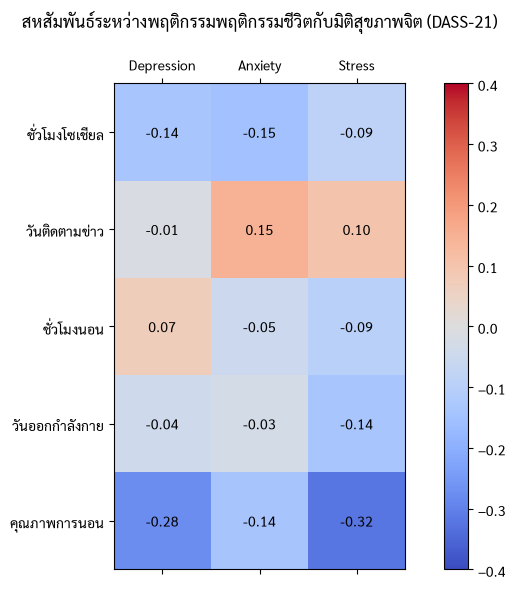

In [4]:
interaction_correlations(df)
interaction_heatmap(df)

**อ่านผล**

- **ข้อ 5** ชั่วโมงใช้โซเชียลมีเดียไม่สัมพันธ์กับชั่วโมงนอน (r = 0.05, p = 0.616) และไม่สัมพันธ์กับคุณภาพการนอน (r = 0.11, p = 0.243)
  ในกลุ่มนี้คนที่ใช้มากกว่าจึงไม่ได้นอนน้อยกว่าหรือนอนแย่กว่า
- สิ่งที่สัมพันธ์กับคะแนนคือ**คุณภาพการนอน** ยิ่งนอนดีคะแนนภาวะซึมเศร้ายิ่งต่ำ (r = −0.28, p = 0.004)
  และความเครียดยิ่งต่ำ (r = −0.32, p < 0.001) ส่วนชั่วโมงนอนและการออกกำลังกายไม่สัมพันธ์กับมิติใด